## Decomposing 48 Years of Market History: Crash, Steep Climb, or Normal Growth?
*Part of a series — Part 1 compared the current AI-driven rally to the dot-com bubble; Part 2 studied whether patience heals crashes over long holding periods.*

**TL;DR** (48 years of S&P 500 history decomposed into three market regimes):
- **Crash & Recovery**: 35% of weeks, 5 episodes — contributes only 2% of the 48-year trend because declines and recoveries cancel each other out
- **Steep Climbing**: 16% of weeks, 36 rallies occurring ~1.3 years apart — delivers 62% of the 48-year returns, even though it's the rarest regime
- **Normal Climbing**: 49% of weeks — occupies nearly half the calendar but contributes 36% of the trend
- **Bottom line**: 62% of the 48-year return came from steep climbs (16% of weeks), while 36% came from normal climbing (49% of weeks). Right now we're in a normal climbing stage—not steep climbing, not a crash.

*Limitation: this three-way decomposition (and the thresholds/parameters used to define it) is my own choice, not a standard or unique way to slice market history — other reasonable definitions would produce different boundaries and numbers.*

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

In [3]:
# S&P 500, weekly resolution, since 1978 (same cutoff established in Part 2)
sp500_weekly = yf.download(
    "^GSPC",
    start="1978-01-01",
    interval="1wk",
    auto_adjust=True
)

print(sp500_weekly.tail())

Cookie fetch from fc.yahoo.com failed (CertificateVerifyError), continuing without it
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC
Date                                                                       
2026-08-23  7711.759766  7771.479980  7638.169922  7663.379883  21421440000
2026-08-30  7718.600098  7756.759766  7611.200195  7697.520020  23813150000
2026-09-06  7656.979980  7717.810059  7580.060059  7717.810059  19479850000
2026-09-13  7650.500000  7657.169922  7507.770020  7611.439941  29343160000
2026-09-20  7743.410156  7782.189941  7662.569824  7692.830078  25040800000


Every market cycle mixes crashes, fast rallies, and everything else in between — slow grinds up, minor pullbacks, sideways stretches — but there's no consistent rule for telling which one you're in, or how much each contributes to long-term returns. Here we build one: a systematic split of 48 years of weekly S&P 500 data into crash & recovery, steep climbing, and everything else ("normal").

### Three-Part Market Decomposition (1978-2026)

#### Part 1: Crash & Recovery Episodes

The first slice of the decomposition is the crashes themselves. We flag every stretch where the market fell at least 25% from a prior all-time high, and follow it through to the point it climbs back to that same peak — treating the fall and the rebound as one combined episode. This isolates the 5 major crash-and-recovery periods since 1978, so the next two parts can focus purely on what the market did the rest of the time.

The 5 crash & recovery episodes below were already identified and studied in Part 2 (peak, trough, max drawdown, and recovery time for each). Here we're not re-deriving that analysis — just re-running the same detection logic to get the episode dates, then plotting them on the full price time series.

In [4]:
# Peak, trough, max drawdown, and recovery time for every crash since 1978, detected algorithmically
# rather than hand-picked: a "crash" is any drawdown of at least 25% from a prior all-time high
# (stricter than the -20% "bear market" convention, to isolate severe crashes rather than routine
# corrections), with double-dips before a new high merged into one episode.
crash_threshold = -0.25

close = sp500_weekly["Close"].squeeze()
close_subset = close

running_peak = close.cummax()
drawdown_series = close / running_peak - 1

in_crash = drawdown_series <= crash_threshold
episode_id = (in_crash != in_crash.shift(fill_value=False)).cumsum()

raw_episodes = []
for ep_id in episode_id[in_crash].unique():
    episode_dates = drawdown_series.index[episode_id == ep_id]
    trough_date = close.loc[episode_dates].idxmin()
    trough_price = close.loc[trough_date]

    peak_price_series = close.loc[:trough_date]
    peak_date = peak_price_series.idxmax()
    peak_price = peak_price_series.max()

    max_drawdown = trough_price / peak_price - 1

    after_trough = close.loc[trough_date:]
    recovered = after_trough[after_trough >= peak_price]
    # If the market hasn't made a new high yet, treat the episode as still open through the latest data
    recovery_date = recovered.index[0] if not recovered.empty else close.index[-1]

    raw_episodes.append({
        "peak_date": peak_date, "peak_price": peak_price,
        "trough_date": trough_date, "max_drawdown": max_drawdown,
        "recovery_date": recovery_date,
    })

# Merge episodes sharing the same peak (no new all-time high in between = same underlying crash)
merged_by_peak = {}
for episode in raw_episodes:
    key = episode["peak_date"]
    if key not in merged_by_peak or episode["max_drawdown"] < merged_by_peak[key]["max_drawdown"]:
        merged_by_peak[key] = episode
crash_stats = sorted(merged_by_peak.values(), key=lambda e: e["peak_date"])

# Reshape into {start_date, end_date, start_price, end_price} for the plots below
crash_episodes_list = [
    {
        "start_date": stat["peak_date"],
        "end_date": stat["recovery_date"],
        "start_price": stat["peak_price"],
        "end_price": close.loc[stat["recovery_date"]],
    }
    for stat in crash_stats
]

# Mark every week that falls inside any crash+recovery episode (peak through new high)
crash_mask = pd.Series(False, index=close_subset.index)
for ep in crash_episodes_list:
    crash_mask.loc[ep["start_date"]:ep["end_date"]] = True

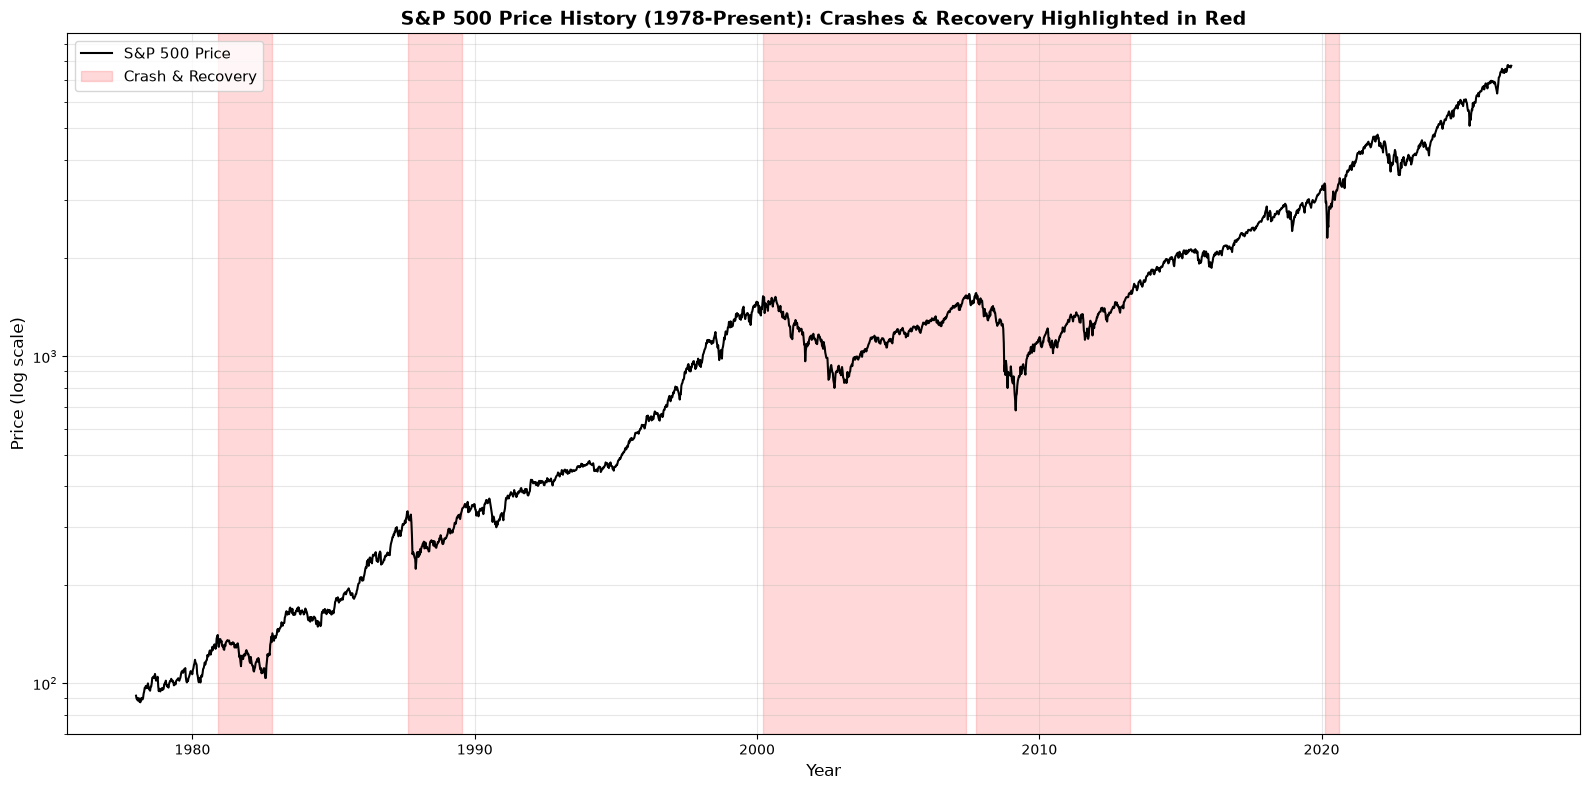


📊 CRASH & RECOVERY EPISODES HIGHLIGHTED (red regions):
Total episodes: 5
  1. 1980-11-23 → 1982-10-31 (1.9 years)
  2. 1987-08-16 → 1989-07-16 (1.9 years)
  3. 2000-03-19 → 2007-05-27 (7.2 years)
  4. 2007-10-07 → 2013-03-24 (5.5 years)
  5. 2020-02-09 → 2020-08-16 (0.5 years)


In [5]:
# Full price history with crashes and recovery marked as red bars
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the price line
ax.plot(close_subset.index, close_subset.values, color='black', linewidth=1.5, zorder=2, label='S&P 500 Price')

# Shade all crash+recovery episodes as red background regions
for episode in crash_episodes_list:
    ax.axvspan(episode['start_date'], episode['end_date'], 
               color='red', alpha=0.15, zorder=1, label='Crash & Recovery' if episode == crash_episodes_list[0] else '')

ax.set_yscale('log')
ax.set_title('S&P 500 Price History (1978-Present): Crashes & Recovery Highlighted in Red', fontsize=14, weight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Price (log scale)', fontsize=12)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n📊 CRASH & RECOVERY EPISODES HIGHLIGHTED (red regions):")
print(f"Total episodes: {len(crash_episodes_list)}")
for i, episode in enumerate(crash_episodes_list, 1):
    duration_years = (episode['end_date'] - episode['start_date']).days / 365.25
    print(f"  {i}. {episode['start_date'].date()} → {episode['end_date'].date()} ({duration_years:.1f} years)")

#### Part 2: Removing the Crashes — What's Left When You Strip Them Out

The chart below strips out every crash & recovery episode entirely and stitches the remaining weeks back-to-back. **This is not a real time series** — the x-axis is just a week count, not a calendar date, since ~35% of the actual weeks (the crash periods) have been deleted and the gaps closed up. It's a way to see what the market looked like **outside major crash episodes**, isolated from the crash years—small pullbacks and noise still included.

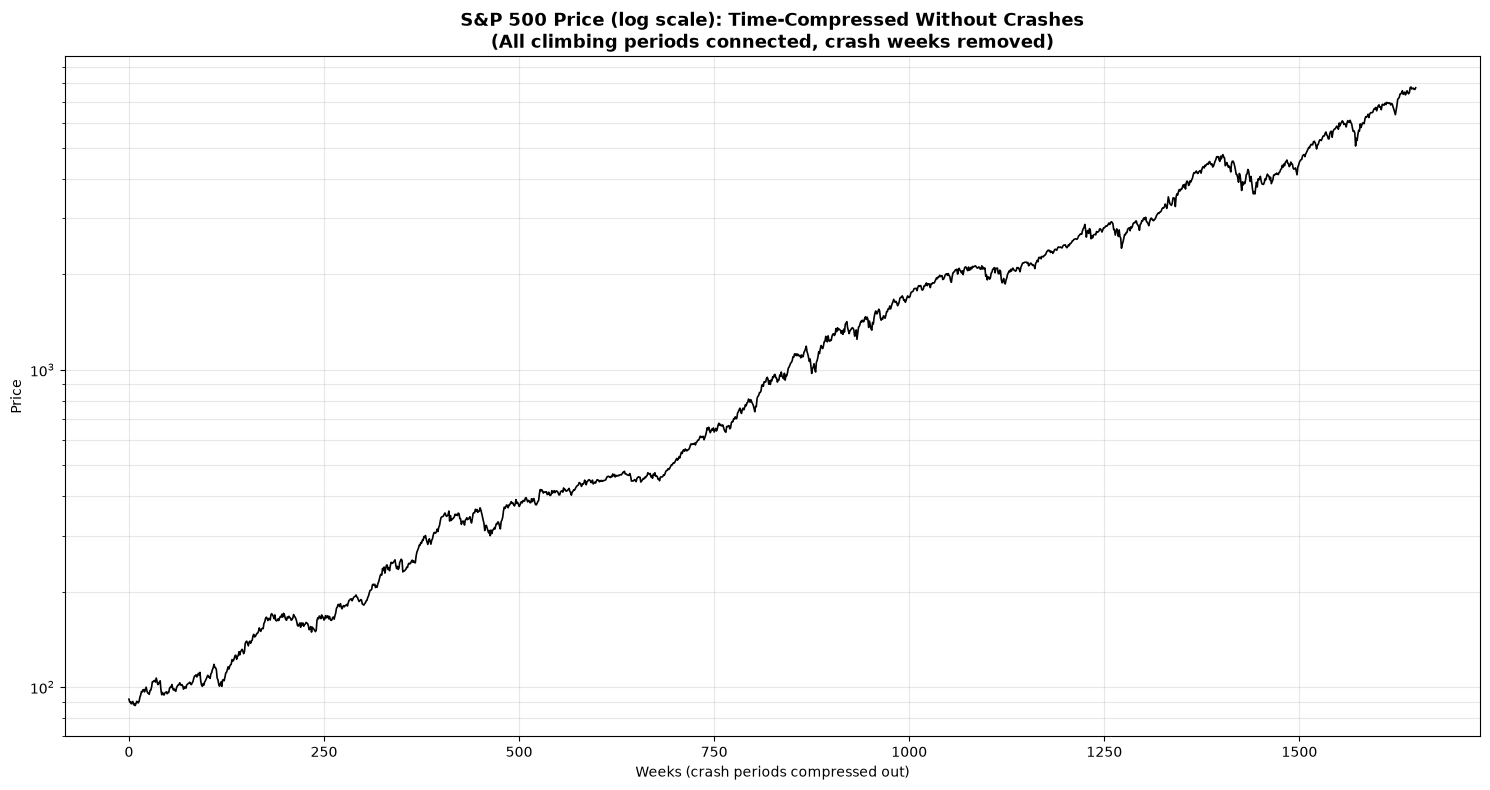


TIME COMPRESSION:
  Original timeline: 2543 weeks (48.9 years)
  Compressed timeline: 1650 weeks (31.7 years)
  Time removed by crashes: 893 weeks (17.2 years)
  Compression ratio: 1.54x


In [6]:
# Alternative visualization: compress time by removing crashes entirely
# Connect climbing periods directly, skipping all crash weeks

fig, ax = plt.subplots(figsize=(15, 8))

# Get only the climbing periods (rest weeks) and plot them sequentially
rest_prices = close_subset[~crash_mask].values
ax.plot(range(len(rest_prices)), rest_prices, color="black", linewidth=1.2)

ax.set_yscale("log")
ax.set_title("S&P 500 Price (log scale): Time-Compressed Without Crashes\n(All climbing periods connected, crash weeks removed)", fontsize=13, weight="bold")
ax.set_xlabel("Weeks (crash periods compressed out)")
ax.set_ylabel("Price")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTIME COMPRESSION:")
print(f"  Original timeline: {len(close_subset)} weeks ({len(close_subset)/52:.1f} years)")
print(f"  Compressed timeline: {(~crash_mask).sum()} weeks ({(~crash_mask).sum()/52:.1f} years)")
print(f"  Time removed by crashes: {crash_mask.sum()} weeks ({crash_mask.sum()/52:.1f} years)")
print(f"  Compression ratio: {len(close_subset)/(~crash_mask).sum():.2f}x")

#### Part 3: Splitting the Climb into Steep vs. Normal Weeks

We saw that crashes (35% of weeks) contribute only 2% to the trend. Now let's flip the question: what if we look for the fastest-growing weeks instead? Do they cluster together? And do they drive *more* of the trend than their calendar share would suggest?

To answer this, we need to split climbing weeks into two groups: the **steep** weeks (fastest growth) and the **normal** weeks (everything else). Here's how:

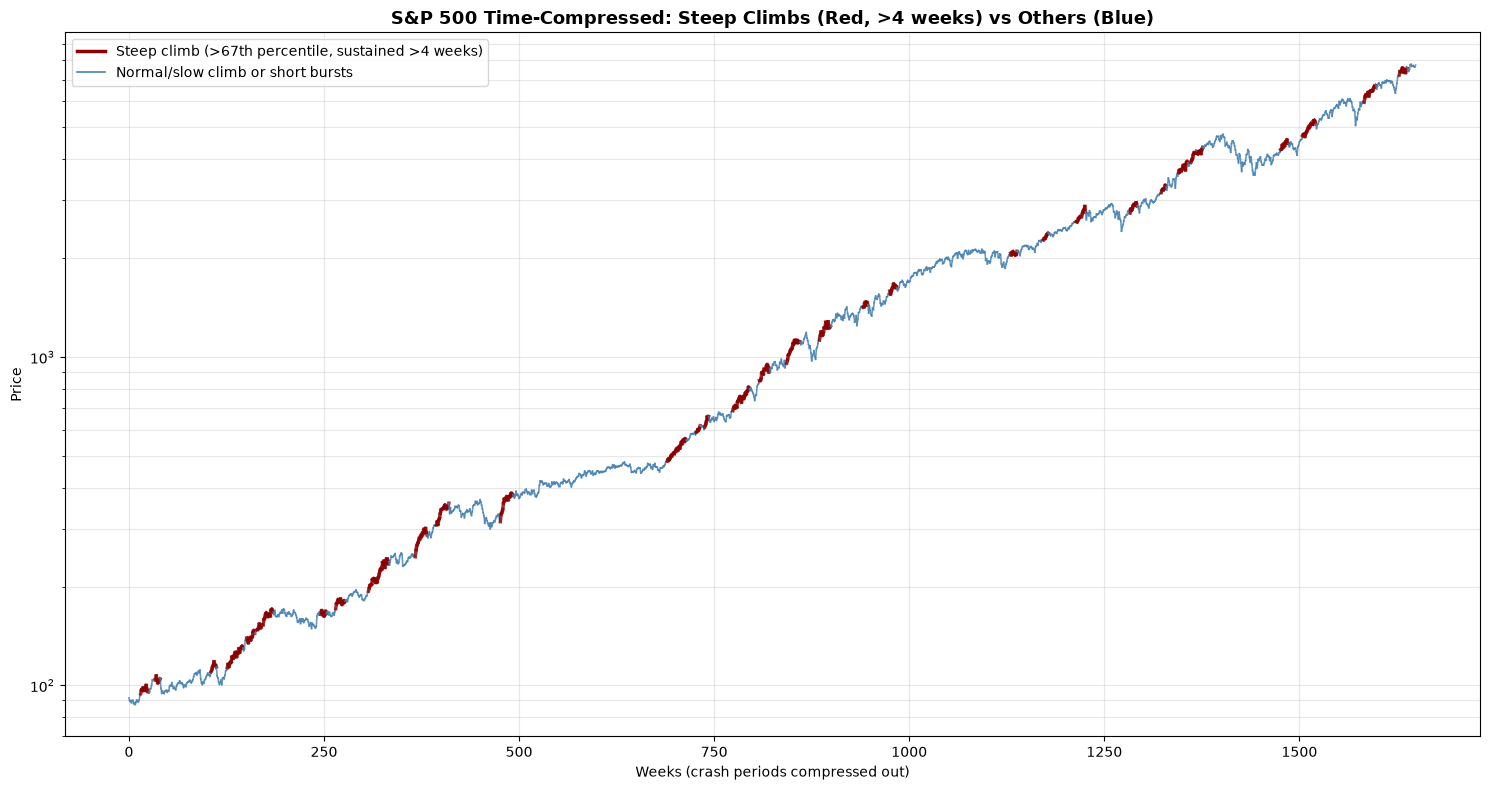


STEEP CLIMBING SEGMENTS (>4 weeks sustained)

Segment 1: 1978-04-16 to 1978-06-18
  Duration: 10 weeks (0.2 years)

Segment 2: 1978-08-27 to 1978-10-01
  Duration: 6 weeks (0.1 years)

Segment 3: 1980-01-06 to 1980-02-17
  Duration: 7 weeks (0.1 years)

Segment 4: 1980-06-01 to 1980-10-12
  Duration: 20 weeks (0.4 years)

Segment 5: 1982-11-07 to 1983-01-09
  Duration: 10 weeks (0.2 years)

Segment 6: 1983-02-06 to 1983-03-20
  Duration: 7 weeks (0.1 years)

Segment 7: 1983-04-03 to 1983-06-26
  Duration: 13 weeks (0.2 years)

Segment 8: 1984-09-02 to 1984-10-14
  Duration: 7 weeks (0.1 years)

Segment 9: 1985-01-13 to 1985-03-31
  Duration: 12 weeks (0.2 years)

Segment 10: 1985-11-03 to 1986-04-27
  Duration: 26 weeks (0.5 years)

Segment 11: 1986-12-28 to 1987-04-05
  Duration: 15 weeks (0.3 years)

Segment 12: 1987-07-05 to 1987-08-09
  Duration: 6 weeks (0.1 years)

Segment 13: 1989-07-23 to 1989-09-24
  Duration: 10 weeks (0.2 years)

Segment 14: 1991-01-06 to 1991-04-21
  Durat

In [7]:
# Mark steep vs gentle sections: show steep climb as red, rest as blue
# Only show RED segments that are >4 weeks long (filter out short bursts)

rest_indices_full = np.where(~crash_mask)[0]
rest_prices_all = close_subset.values[rest_indices_full]
rest_dates = close_subset.index[rest_indices_full]

# Calculate weekly returns for coloring
weekly_returns_climb = np.diff(np.log(rest_prices_all))
window = 13  # ~3 months
smoothed_returns = np.convolve(weekly_returns_climb, np.ones(window)/window, mode='valid')
smoothed_returns_padded = np.concatenate([np.full(window-1, smoothed_returns[0]), smoothed_returns])

steep_threshold = np.percentile(smoothed_returns_padded, 67)

# Identify all contiguous steep segments (weeks > steep_threshold)
is_steep = smoothed_returns_padded > steep_threshold

# Find contiguous segments
# rest_dates has crash weeks excised, so array-adjacent entries can be calendar-years apart;
# break a run there too, or a segment would silently bridge over an excised crash
steep_segments = []
segment_start = None
for i in range(len(is_steep)):
    calendar_gap = i > 0 and (rest_dates[i] - rest_dates[i - 1]) > pd.Timedelta(weeks=1)
    if is_steep[i] and not calendar_gap:
        if segment_start is None:
            segment_start = i
    else:
        if segment_start is not None:
            segment_length = i - segment_start
            steep_segments.append((segment_start, i, segment_length))
            segment_start = None
        if is_steep[i]:
            segment_start = i

# Don't forget the last segment if it ends at the boundary
if segment_start is not None:
    segment_length = len(is_steep) - segment_start
    steep_segments.append((segment_start, len(is_steep), segment_length))

# Filter to only segments >4 weeks
long_steep_segments = [(start, end, length) for start, end, length in steep_segments if length > 4]

# Mark which weeks belong to long steep segments
is_long_steep = np.zeros(len(rest_prices_all), dtype=bool)
for start, end, _ in long_steep_segments:
    is_long_steep[start:end] = True

# Plot with coloring
fig, ax = plt.subplots(figsize=(15, 8))

for i in range(len(rest_prices_all) - 1):
    if is_long_steep[i]:
        # Part of a long steep segment
        color = 'darkred'
        linewidth = 2.5
    else:
        # Either gentle climb or short burst (filtered out)
        color = 'steelblue'
        linewidth = 1.2
    
    ax.plot(range(i, i+2), rest_prices_all[i:i+2], color=color, linewidth=linewidth, alpha=0.8)

ax.set_yscale("log")
ax.set_title("S&P 500 Time-Compressed: Steep Climbs (Red, >4 weeks) vs Others (Blue)", fontsize=13, weight="bold")
ax.set_xlabel("Weeks (crash periods compressed out)")
ax.set_ylabel("Price")
ax.grid(True, which="both", alpha=0.3)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='darkred', lw=2.5, label='Steep climb (>67th percentile, sustained >4 weeks)'),
    Line2D([0], [0], color='steelblue', lw=1.2, label='Normal/slow climb or short bursts')
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

# Statistics
print("\n" + "="*80)
print("STEEP CLIMBING SEGMENTS (>4 weeks sustained)")
print("="*80)
for idx, (start, end, length) in enumerate(long_steep_segments, 1):
    start_date = rest_dates[start]
    end_date = rest_dates[end-1]
    print(f"\nSegment {idx}: {start_date.date()} to {end_date.date()}")
    print(f"  Duration: {length} weeks ({length/52:.1f} years)")

print(f"\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Growth Rate Statistics:")
print(f"  Slowest 25%: {np.percentile(smoothed_returns_padded, 25):.4f} ({np.percentile(smoothed_returns_padded, 25)*100:.2f}% per week)")
print(f"  Median:      {np.median(smoothed_returns_padded):.4f} ({np.median(smoothed_returns_padded)*100:.2f}% per week)")
print(f"  Fastest 25%: {np.percentile(smoothed_returns_padded, 75):.4f} ({np.percentile(smoothed_returns_padded, 75)*100:.2f}% per week)")
print(f"  Steep threshold: {steep_threshold:.4f} ({steep_threshold*100:.2f}% per week)")
print(f"\nSegment breakdown:")
print(f"  Total steep segments identified: {len(steep_segments)}")
print(f"  Long segments (>4 weeks): {len(long_steep_segments)} segments, {sum(length for _, _, length in long_steep_segments)} weeks total")
print(f"  Short bursts (≤4 weeks): {len(steep_segments) - len(long_steep_segments)} segments, {sum(length for start, end, length in steep_segments if length <= 4)} weeks total")
print(f"  Red weeks shown (long steep): {is_long_steep.sum()} out of {len(rest_prices_all)} ({100*is_long_steep.sum()/len(rest_prices_all):.1f}%)")

**A note on parameter choices**: The 67th percentile and 13-week smoothing window are reasonable, round choices—not "ground truth." The 67th percentile splits climbing weeks into thirds and calls the fastest third "steep"; the 13-week window is long enough to filter out single-week noise but short enough to catch multi-month rallies. Pick different parameters and the count, length, and split of steep vs. normal weeks would shift. This is one reasonable way to slice the data, not the only way.

#### Isolating the Steep Segments Alone

Now we pull out *only* the steep-climb weeks identified above, drop everything else (crashes, normal climbs, short bursts), and stitch the segments together back-to-back. Like the earlier time-compressed chart, the x-axis here is just a week count, not a calendar date — this shows what the market's fastest climbing stretches would look like end-to-end if you could line them all up. **This still contains ups and downs** — weeks outside major crashes — but they're the market's most explosive growth periods.

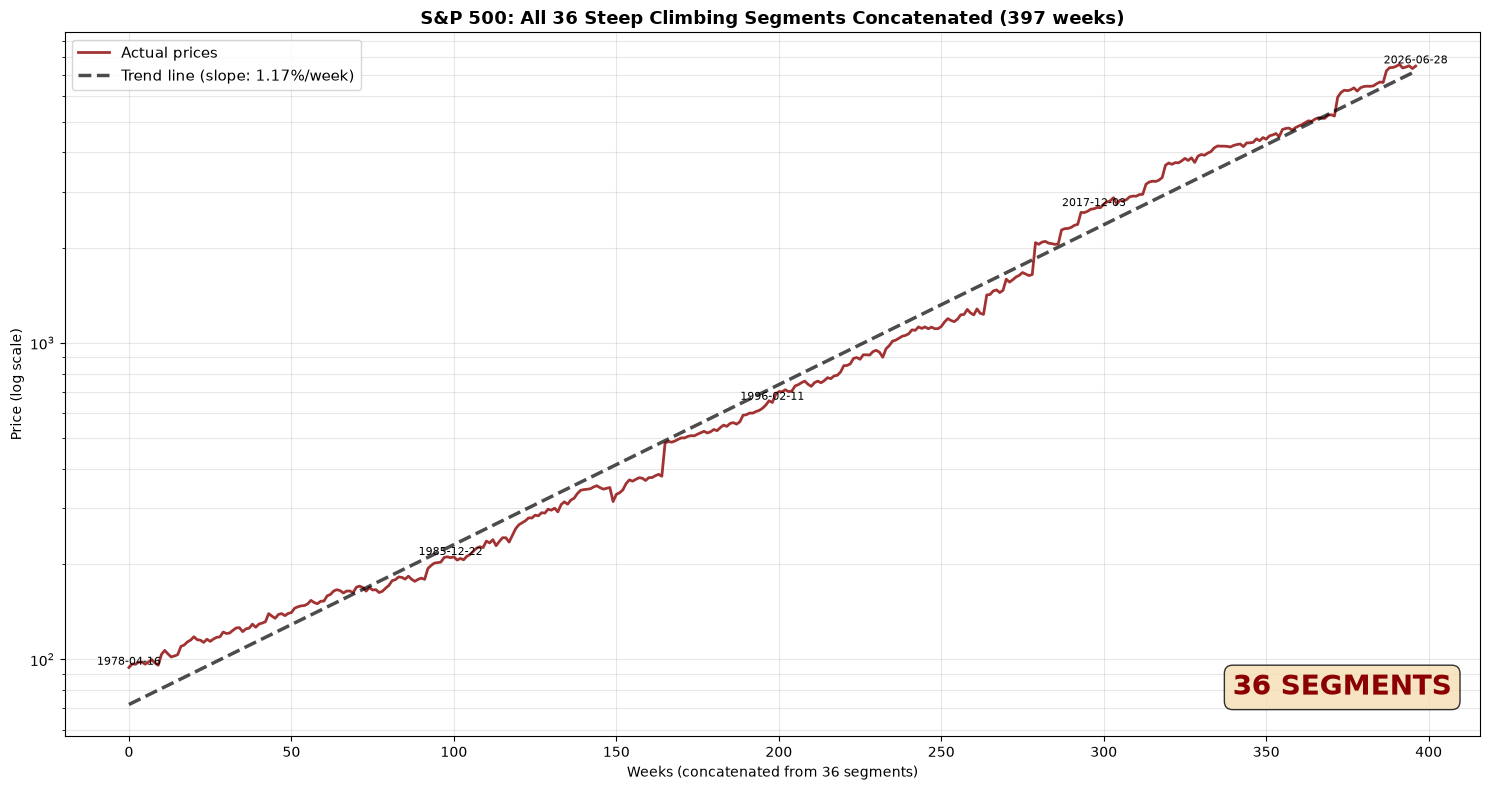


Total steep climbing weeks: 397
Price range: $94.34 to $7580.06
Total return: 7832.2%
Annualized return (if continuous): 77.3%

TREND LINE:
  Slope (weekly log return): 0.011631
  Weekly growth rate: 1.17%
  Annualized equivalent: 83.1%


In [8]:
# Extract only steep climbing segments and plot continuously
steep_prices = rest_prices_all[is_long_steep]
steep_dates = rest_dates[is_long_steep]

# Calculate trend line in log space
log_steep_prices = np.log(steep_prices)
x = np.arange(len(steep_prices))
slope, intercept = np.polyfit(x, log_steep_prices, 1)
trend_line = np.exp(intercept + slope * x)

# Convert slope to weekly percentage
weekly_pct = (np.exp(slope) - 1) * 100

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(range(len(steep_prices)), steep_prices, color='darkred', linewidth=2, alpha=0.8, label='Actual prices')
ax.plot(range(len(steep_prices)), trend_line, color='black', linewidth=2.5, linestyle='--', alpha=0.7, label=f'Trend line (slope: {weekly_pct:.2f}%/week)')

ax.set_yscale("log")
ax.set_title(f"S&P 500: All {len(long_steep_segments)} Steep Climbing Segments Concatenated ({len(steep_prices)} weeks)", fontsize=13, weight="bold")
ax.set_xlabel(f"Weeks (concatenated from {len(long_steep_segments)} segments)")
ax.set_ylabel("Price (log scale)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

# Add large text box showing number of segments
ax.text(0.98, 0.05, f'{len(long_steep_segments)} SEGMENTS', transform=ax.transAxes, 
        fontsize=20, weight='bold', color='darkred', 
        ha='right', va='bottom', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Add date annotations at key points
for i in [0, len(steep_prices)//4, len(steep_prices)//2, 3*len(steep_prices)//4, len(steep_prices)-1]:
    if i < len(steep_dates):
        ax.text(i, steep_prices[i], steep_dates[i].strftime('%Y-%m-%d'), 
                fontsize=8, rotation=0, ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nTotal steep climbing weeks: {len(steep_prices)}")
print(f"Price range: ${steep_prices.min():.2f} to ${steep_prices.max():.2f}")
print(f"Total return: {(steep_prices[-1] / steep_prices[0] - 1) * 100:.1f}%")
print(f"Annualized return (if continuous): {((steep_prices[-1] / steep_prices[0]) ** (52 / len(steep_prices)) - 1) * 100:.1f}%")
print(f"\nTREND LINE:")
print(f"  Slope (weekly log return): {slope:.6f}")
print(f"  Weekly growth rate: {weekly_pct:.2f}%")
print(f"  Annualized equivalent: {((np.exp(slope))**52 - 1) * 100:.1f}%")

#### Isolating the Normal Segments Alone

Everything that's *not* steep — slower climbing weeks with their pullbacks, minor reversals, and sideways stretches included. They're still climbing on balance, just not with the explosive speed of the steep rallies. Again, crashes and steep weeks are removed, so the x-axis is a week count, not calendar time.

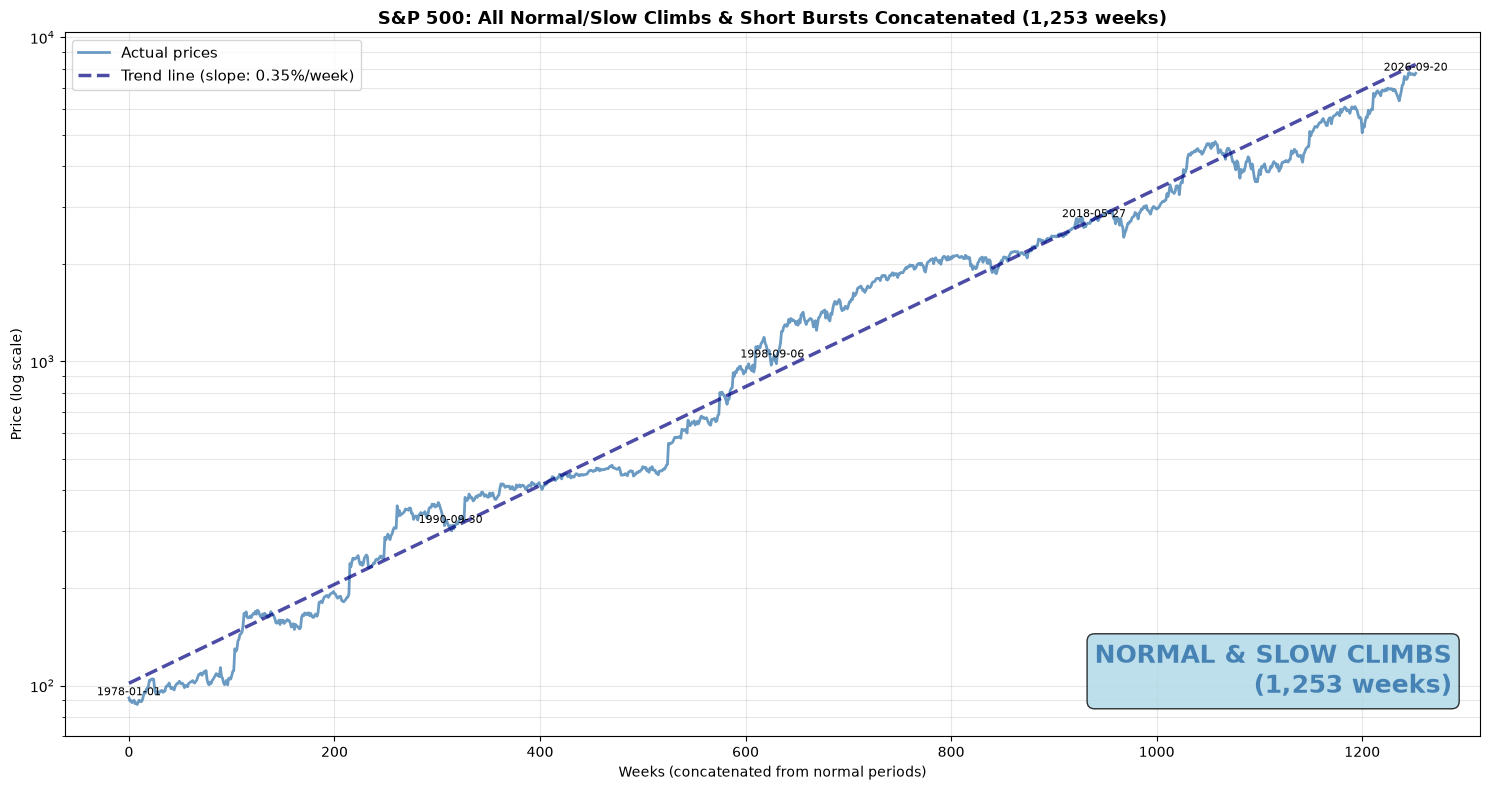


Total normal/slow climbing weeks: 1253
Price range: $87.45 to $7785.76
Total return: 8351.7%
Annualized return (if continuous): 20.2%

TREND LINE:
  Slope (weekly log return): 0.003511
  Weekly growth rate: 0.35%
  Annualized equivalent: 20.0%


In [10]:
# Extract normal/slow climbs and short bursts (NOT steep)
normal_prices = rest_prices_all[~is_long_steep]
normal_dates = rest_dates[~is_long_steep]

# Calculate trend line in log space
log_normal_prices = np.log(normal_prices)
x_normal = np.arange(len(normal_prices))
slope_normal, intercept_normal = np.polyfit(x_normal, log_normal_prices, 1)
trend_line_normal = np.exp(intercept_normal + slope_normal * x_normal)

# Convert slope to weekly percentage
weekly_pct_normal = (np.exp(slope_normal) - 1) * 100

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(range(len(normal_prices)), normal_prices, color='steelblue', linewidth=2, alpha=0.8, label='Actual prices')
ax.plot(range(len(normal_prices)), trend_line_normal, color='navy', linewidth=2.5, linestyle='--', alpha=0.7, label=f'Trend line (slope: {weekly_pct_normal:.2f}%/week)')

ax.set_yscale("log")
ax.set_title(f"S&P 500: All Normal/Slow Climbs & Short Bursts Concatenated ({len(normal_prices):,} weeks)", fontsize=13, weight="bold")
ax.set_xlabel("Weeks (concatenated from normal periods)")
ax.set_ylabel("Price (log scale)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

# Add large text box showing composition
ax.text(0.98, 0.05, f'NORMAL & SLOW CLIMBS\n({len(normal_prices):,} weeks)', transform=ax.transAxes, 
        fontsize=18, weight='bold', color='steelblue', 
        ha='right', va='bottom', 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Add date annotations at key points
for i in [0, len(normal_prices)//4, len(normal_prices)//2, 3*len(normal_prices)//4, len(normal_prices)-1]:
    if i < len(normal_dates):
        ax.text(i, normal_prices[i], normal_dates[i].strftime('%Y-%m-%d'), 
                fontsize=8, rotation=0, ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nTotal normal/slow climbing weeks: {len(normal_prices)}")
print(f"Price range: ${normal_prices.min():.2f} to ${normal_prices.max():.2f}")
print(f"Total return: {(normal_prices[-1] / normal_prices[0] - 1) * 100:.1f}%")
print(f"Annualized return (if continuous): {((normal_prices[-1] / normal_prices[0]) ** (52 / len(normal_prices)) - 1) * 100:.1f}%")
print(f"\nTREND LINE:")
print(f"  Slope (weekly log return): {slope_normal:.6f}")
print(f"  Weekly growth rate: {weekly_pct_normal:.2f}%")
print(f"  Annualized equivalent: {((np.exp(slope_normal))**52 - 1) * 100:.1f}%")

#### Steep vs. Normal, Side by Side

We now have trend lines for both groups — steep (36 segments, 397 weeks) and normal (1,253 weeks). Putting the two weekly growth rates next to each other makes the speed gap between them concrete.

In [11]:
print("\nSPEED COMPARISON: STEEP vs NORMAL CLIMBS")
print("=" * 60)

print(f"\nSTEEP CLIMBS ({len(long_steep_segments)} segments, {len(steep_prices)} weeks):")
print(f"  Weekly growth: {weekly_pct:.2f}%")
print(f"  Annualized: {((np.exp(slope))**52 - 1) * 100:.1f}%")

print(f"\nNORMAL/SLOW CLIMBS ({len(normal_prices)} weeks):")
print(f"  Weekly growth: {weekly_pct_normal:.2f}%")
print(f"  Annualized: {((np.exp(slope_normal))**52 - 1) * 100:.1f}%")

print(f"\nCOMPARISON:")
print(f"  Steep is {weekly_pct / weekly_pct_normal:.1f}x faster")
print(f"  Difference: {weekly_pct - weekly_pct_normal:.2f}% per week")
print(f"  Annualized difference: {((np.exp(slope))**52 - 1) * 100 - ((np.exp(slope_normal))**52 - 1) * 100:.1f} percentage points")



SPEED COMPARISON: STEEP vs NORMAL CLIMBS

STEEP CLIMBS (36 segments, 397 weeks):
  Weekly growth: 1.17%
  Annualized: 83.1%

NORMAL/SLOW CLIMBS (1253 weeks):
  Weekly growth: 0.35%
  Annualized: 20.0%

COMPARISON:
  Steep is 3.3x faster
  Difference: 0.82% per week
  Annualized difference: 63.1 percentage points


####  Putting It All Together: The Full Three-Part Picture

In [12]:
# THREE-PART DECOMPOSITION OF 48-YEAR HISTORY: summary table
total_weeks = len(close_subset)
crash_weeks = crash_mask.sum()
climbing_weeks = (~crash_mask).sum()
steep_weeks = is_long_steep.sum()
normal_weeks = climbing_weeks - steep_weeks

crash_pct = (crash_weeks / total_weeks) * 100
steep_pct = (steep_weeks / total_weeks) * 100
normal_pct = (normal_weeks / total_weeks) * 100

# Computed from crash_mask directly (independent of the later "regime" classification below)
weekly_returns_all = close.pct_change()
crash_weekly_avg = weekly_returns_all[crash_mask].mean()
crash_total_return = (1 + weekly_returns_all[crash_mask]).prod() - 1
overall_total_return = close.iloc[-1] / close.iloc[0] - 1

# Weekly volatility per period, using each week's actual return (not the concatenated/trend-fit arrays,
# which would show spurious jumps at the seams between disjoint segments)
steep_mask = pd.Series(close_subset.index.isin(steep_dates), index=close_subset.index)
normal_mask = (~crash_mask) & (~steep_mask)
crash_weekly_std = weekly_returns_all[crash_mask].std()
steep_weekly_std = weekly_returns_all[steep_mask].std()
normal_weekly_std = weekly_returns_all[normal_mask].std()
overall_weekly_std = weekly_returns_all.std()

summary_table = pd.DataFrame({
    'Period': ['Crash & Recovery', 'Steep Climbing', 'Normal Climbing', 'TOTAL'],
    'Weeks': [crash_weeks, steep_weeks, normal_weeks, total_weeks],
    '% of Total': [f'{crash_pct:.1f}%', f'{steep_pct:.1f}%', f'{normal_pct:.1f}%', '100.0%'],
    'Years': [f'{crash_weeks/52:.1f}', f'{steep_weeks/52:.1f}', f'{normal_weeks/52:.1f}', f'{total_weeks/52:.1f}'],
    'Avg Weekly Return': [f'{crash_weekly_avg:+.3%}', f'{weekly_pct/100:+.3%}', f'{weekly_pct_normal/100:+.3%}', '-'],
    'Weekly Volatility': [f'{crash_weekly_std:.3%}', f'{steep_weekly_std:.3%}', f'{normal_weekly_std:.3%}', f'{overall_weekly_std:.3%}'],
    'Total Return': [f'{crash_total_return:+.1%}', f'{(steep_prices[-1]/steep_prices[0]-1)*100:+.1f}%', f'{(normal_prices[-1]/normal_prices[0]-1)*100:+.1f}%', f'{overall_total_return:+.1%}']
})

print("THREE-PART DECOMPOSITION: SUMMARY TABLE (1978-2026)")
display(summary_table)


THREE-PART DECOMPOSITION: SUMMARY TABLE (1978-2026)


,Period,Weeks,% of Total,Years,Avg Weekly Return,Weekly Volatility,Total Return
0,Crash & Recovery,893,35.1%,17.2,+0.051%,2.776%,+10.9%
1,Steep Climbing,397,15.6%,7.6,+1.170%,1.633%,+7832.2%
2,Normal Climbing,1253,49.3%,24.1,+0.352%,2.001%,+8351.7%
3,TOTAL,2543,100.0%,48.9,-,2.267%,+8351.7%


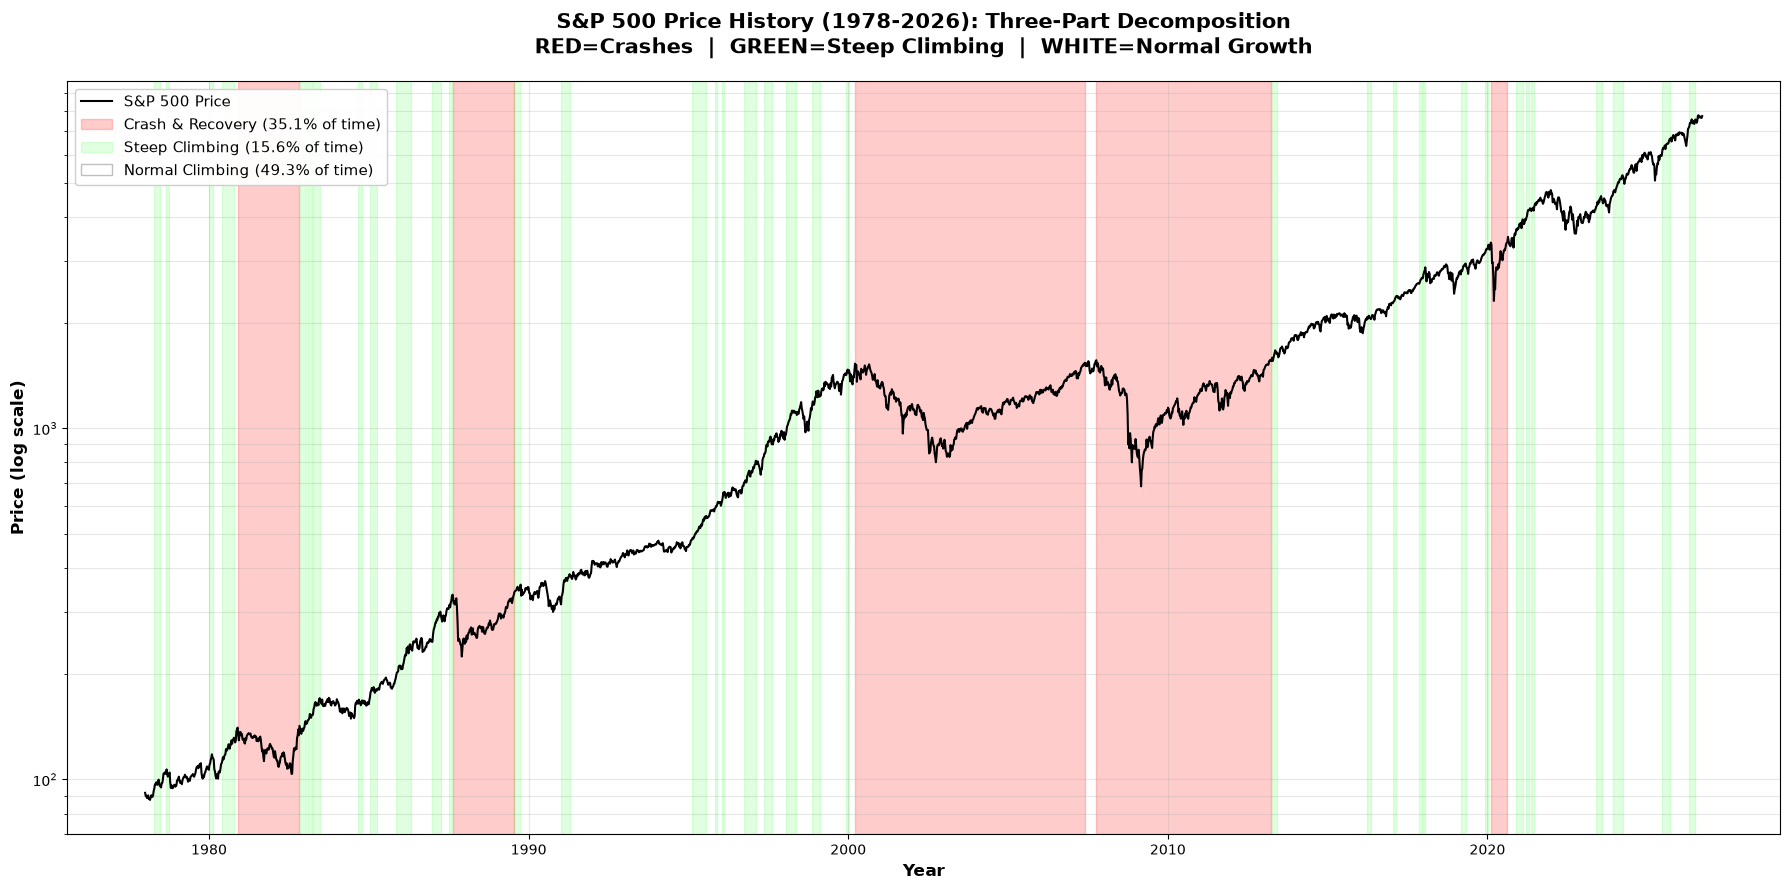

In [13]:
# THREE-PART MARKET DECOMPOSITION (1978-2026)
# ============================================
# METHODOLOGY NOTE:
# This is MY approach to decomposing 48 years of S&P 500 history into three market regimes.
# 
# Definitions:
#   1. Crashes & Recovery (RED): Periods with >25% drawdown from peak, including recovery phase
#   2. Steep Climbing (GREEN): Weeks in >67th percentile growth, in segments >4 weeks long
#   3. Normal Climbing (WHITE): All other climbing weeks (steady, boring growth)
#
# IMPORTANT LIMITATIONS:
#   - This is ONE possible decomposition method - other approaches (technical, regime-switching, etc.) 
#     would likely produce different breakdowns
#   - The 25% crash threshold and 67th percentile cutoff are arbitrary choices based on my analysis
#   - Recovery periods contain steep climbing too - I grouped them with crashes for narrative clarity
#   - Weekly resolution smooths intraday volatility and masks short-term regime changes
#   - This analysis assumes past patterns continue - future markets may behave differently
#
# RED = Crash & Recovery | GREEN = Steep Climbing | WHITE = Normal Climbing

fig, ax = plt.subplots(figsize=(18, 9))

# Plot the price line on top
ax.plot(close_subset.index, close_subset.values, color='black', linewidth=1.5, zorder=5, label='S&P 500 Price')

# Shade crash+recovery episodes as RED
for episode in crash_episodes_list:
    ax.axvspan(episode['start_date'], episode['end_date'], 
               color='#FF0000', alpha=0.2, zorder=1, label='Crash & Recovery' if episode == crash_episodes_list[0] else '')

# Shade steep climbing segments as GREEN
# Need to map steep segment dates back to the full timeline
# rest_dates has crash weeks excised, so array-adjacent entries can be calendar-years apart;
# break a run there too, or the green span would bridge (and overlap) the excised crash region
steep_date_ranges = []
current_steep_start = None
for i, date in enumerate(rest_dates):
    calendar_gap = i > 0 and (date - rest_dates[i-1]) > pd.Timedelta(weeks=1)
    if is_long_steep[i] and not calendar_gap:
        if current_steep_start is None:
            current_steep_start = date
    else:
        if current_steep_start is not None:
            steep_date_ranges.append((current_steep_start, rest_dates[i-1]))
            current_steep_start = None
        if is_long_steep[i]:
            current_steep_start = date

# Don't forget the last segment if it ends at the boundary
if current_steep_start is not None:
    steep_date_ranges.append((current_steep_start, rest_dates[-1]))

# Plot green regions for steep climbs
for i, (start_date, end_date) in enumerate(steep_date_ranges):
    ax.axvspan(start_date, end_date, 
               color='lime', alpha=0.12, zorder=2, label='Steep Climbing (>67th %ile)' if i == 0 else '')

ax.set_yscale('log')
ax.set_title('S&P 500 Price History (1978-2026): Three-Part Decomposition\nRED=Crashes  |  GREEN=Steep Climbing  |  WHITE=Normal Growth', 
             fontsize=15, weight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, weight='bold')
ax.set_ylabel('Price (log scale)', fontsize=12, weight='bold')
ax.grid(True, which='both', alpha=0.3)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    ax.get_lines()[0],  # Price line
    Patch(facecolor='#FF0000', alpha=0.2, edgecolor='#FF0000', label=f'Crash & Recovery ({crash_pct:.1f}% of time)'),
    Patch(facecolor='lime', alpha=0.12, edgecolor='lime', label=f'Steep Climbing ({steep_pct:.1f}% of time)'),
    Patch(facecolor='white', alpha=0.5, edgecolor='gray', label=f'Normal Climbing ({normal_pct:.1f}% of time)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

### Which Regime Actually Drives the 48-Year Trend?

Time share (the table above) is one lens; another is: how much of the market's actual long-run growth was *built* by each regime? Weekly log-returns sum up exactly across time — unlike compounding percentage returns, they don't need every week to be present in one continuous stretch — so splitting the total log-return by regime gives each one's exact share of the overall trend, not just its share of the calendar.

**What is "Equivalent Growth Factor"?** It's how much $1 invested at the start of each regime's weeks would have grown by the end. Mathematically, it's e^(log_return). For example:
- If crashes have a 0.98x factor, $1 becomes $0.98 (you lost 2%)
- If steep climbs have a 50x factor, $1 becomes $50
- If normal climbs have a 17x factor, $1 becomes $17
- The **total** of 84.11x means $1 in 1978 became $84.11 by 2026

So a regime's "contribution" can be viewed two ways: as a percentage of the total trend (middle column) *or* as this growth multiplier (right column). They're saying the same thing, just different units.


In [14]:
# Decompose the total log-return (the actual 48-year trend) into each regime's exact additive share -
# log-returns sum across any partition of time, so these three contributions add up to the total, unlike
# compounding % returns computed on separately concatenated series (which don't add up this way)
log_returns_all = np.log(close).diff()

crash_log_contribution = log_returns_all[crash_mask].sum()
steep_log_contribution = log_returns_all[steep_mask].sum()
normal_log_contribution = log_returns_all[normal_mask].sum()
total_log_return = log_returns_all.sum()

contribution_table = pd.DataFrame({
    'Period': ['Crash & Recovery', 'Steep Climbing', 'Normal Climbing', 'TOTAL'],
    '% of Total Trend': [
        f'{crash_log_contribution / total_log_return:.1%}',
        f'{steep_log_contribution / total_log_return:.1%}',
        f'{normal_log_contribution / total_log_return:.1%}',
        '100.0%',
    ],
    'Equivalent Growth Factor': [
        f'{np.exp(crash_log_contribution):.2f}x',
        f'{np.exp(steep_log_contribution):.2f}x',
        f'{np.exp(normal_log_contribution):.2f}x',
        f'{np.exp(total_log_return):.2f}x',
    ],
})

print("WHICH REGIME DRIVES THE OVERALL 48-YEAR TREND?")
print("(log-returns sum exactly across time, so these shares add to 100%)\n")
display(contribution_table)

WHICH REGIME DRIVES THE OVERALL 48-YEAR TREND?
(log-returns sum exactly across time, so these shares add to 100%)



,Period,% of Total Trend,Equivalent Growth Factor
0,Crash & Recovery,2.3%,1.11x
1,Steep Climbing,62.0%,15.66x
2,Normal Climbing,35.7%,4.87x
3,TOTAL,100.0%,84.52x


**Steep Climbing contributes the most to the 48-year trend — not Normal Climbing.** This flips the earlier time-share story: Steep Climbing is only 16% of weeks, but it built **62%** of the entire 48-year trend, nearly double Normal Climbing's 36%, despite Normal Climbing covering three times as many weeks. Crash & Recovery, at 35% of weeks, contributed almost nothing net (2%) — its declines and recoveries largely cancel out. By calendar time, "normal" dominates; by actual growth delivered, the steep rallies do.

### So, Which Regime Are We in Right Now?

In [15]:
# Classify the most recent week using the same three-part decomposition (Crash & Recovery / Steep Climbing / Normal Climbing)
latest_date = close.index[-1]

if crash_mask.loc[latest_date]:
    current_regime = "Crash & Recovery"
elif latest_date in steep_dates:
    current_regime = "Steep Climbing"
else:
    current_regime = "Normal Climbing"

print(f"Latest data point: {latest_date.date()}")
print(f"Current regime: {current_regime}")

Latest data point: 2026-09-20
Current regime: Normal Climbing


### The Big Picture: Why This Split Matters

**Most long-term returns are compressed into short bursts, not gradual climbing.** Steep climbs occupy just 16% of weeks but deliver 62% of the 48-year trend. Normal climbing dominates the calendar (49%) but contributes only 36%. Crashes add up to nearly nothing (2%).

**What this means for investors:**
- **Don't try to time rallies** — the gains are sharp and brief, impossible to predict
- **Patience through noise matters** — 49% of weeks are normal periods with lower returns per week, but staying put is essential
- **Crashes aren't permanent** — despite five major drawdowns since 1978, the market is up 84x

**Right now:** We're in a normal climbing stage—not steep climbing, not a crash. The key is staying in the market long enough to capture the rallies when they come.